# Question 1: Data Preparation and Encoding

## Discussion

The Automobile dataset was first loaded and inspected to understand its structure, data types and missing values. The dataset contains both numerical and categorical variables. Missing values represented by `?` were identified and treated before applying machine learning models.

Categorical variables will be converted into numerical values using encoding. The dataset will also be divided into training and testing data so that the models can be trained and evaluated on unseen data.

In [1]:
import pandas as pd
import numpy as np

columns = [
    "symboling", "normalized-losses", "make", "fuel-type",
    "aspiration", "num-of-doors", "body-style", "drive-wheels",
    "engine-location", "wheel-base", "length", "width", "height",
    "curb-weight", "engine-type", "num-of-cylinders",
    "engine-size", "fuel-system", "bore", "stroke",
    "compression-ratio", "horsepower", "peak-rpm",
    "city-mpg", "highway-mpg", "price"
]

data = pd.read_csv("imports-85.data",names=columns,na_values="?")
data.head()

#dataset structure
data.info()

# missing values
print("\nMissing values in each column:")
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-of-doors       203 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb-weight        205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-of-cylinders   205 non-null    object 
 16  engine-size        205 non

In [2]:
# Fill missing numerical values with the median
numerical_columns = ["normalized-losses","bore","stroke","horsepower","peak-rpm"]

for column in numerical_columns:
    data[column] = data[column].fillna(data[column].median())

# Fill missing value in num of doors with the mode
data["num-of-doors"] = data["num-of-doors"].fillna(
    data["num-of-doors"].mode()[0]
)

# Remove rows where price is missing
data = data.dropna(subset=["price"])

# Check missing values after cleaning
print("Missing values after cleaning:")
print(data.isnull().sum())

print("\nDataset shape after cleaning:")
print(data.shape)

Missing values after cleaning:
symboling            0
normalized-losses    0
make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

Dataset shape after cleaning:
(201, 26)


In [3]:
# Median price
median_price =data["price"].median()

# Create LuxuryCar
data["LuxuryCar"]=np.where(data["price"]>median_price,1,0)

print("Median price:", median_price)

print("\nLuxuryCar distribution:")
print(data["LuxuryCar"].value_counts())

Median price: 10295.0

LuxuryCar distribution:
LuxuryCar
0    101
1    100
Name: count, dtype: int64


In [4]:
# input features and target variables
X =data.drop(["price", "LuxuryCar"], axis=1)

y_regression =data["price"]
y_classification =data["LuxuryCar"]

# Convert categorical variables into numerical variables
X_encoded =pd.get_dummies(X, drop_first=True)

print("Original number of features:", X.shape[1])
print("Number of features after encoding:", X_encoded.shape[1])

X_encoded.head()

Original number of features: 25
Number of features after encoding: 64


,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,...,num-of-cylinders_three,num-of-cylinders_twelve,num-of-cylinders_two,fuel-system_2bbl,fuel-system_4bbl,fuel-system_idi,fuel-system_mfi,fuel-system_mpfi,fuel-system_spdi,fuel-system_spfi
0,3,115.0,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,False,False,False,False,False,False,False,True,False,False
1,3,115.0,88.6,168.8,64.1,48.8,2548,130,3.47,2.68,...,False,False,False,False,False,False,False,True,False,False
2,1,115.0,94.5,171.2,65.5,52.4,2823,152,2.68,3.47,...,False,False,False,False,False,False,False,True,False,False
3,2,164.0,99.8,176.6,66.2,54.3,2337,109,3.19,3.40,...,False,False,False,False,False,False,False,True,False,False
4,2,164.0,99.4,176.6,66.4,54.3,2824,136,3.19,3.40,...,False,False,False,False,False,False,False,True,False,False


In [5]:
from sklearn.model_selection import train_test_split

# Split data for regression
X_train_reg, X_test_reg, y_train_reg,y_test_reg = train_test_split(X_encoded, y_regression,test_size=0.2, random_state=42)

# Split data for classification
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_encoded,y_classification,test_size=0.2,random_state=42,stratify=y_classification)

print("Regression Training Data:", X_train_reg.shape)
print("Regression Testing Data:", X_test_reg.shape)

print("\nClassification Training Data:",X_train_class.shape)
print("Classification Testing Data:",X_test_class.shape)

Regression Training Data: (160, 64)
Regression Testing Data: (41, 64)

Classification Training Data: (160, 64)
Classification Testing Data: (41, 64)


In [6]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler =StandardScaler()

# Scale the training data
X_train_reg_scaled = scaler.fit_transform(X_train_reg)

# same scaler for the testing data
X_test_reg_scaled = scaler.transform(X_test_reg)

# scaled data for classification
X_train_class_scaled = scaler.fit_transform(X_train_class)
X_test_class_scaled = scaler.transform(X_test_class)

print("Regression training data after scaling:", X_train_reg_scaled.shape)
print("Regression testing data after scaling:", X_test_reg_scaled.shape)

print("\nClassification training data after scaling:", X_train_class_scaled.shape)
print("Classification testing data after scaling:", X_test_class_scaled.shape)

Regression training data after scaling: (160, 64)
Regression testing data after scaling: (41, 64)

Classification training data after scaling: (160, 64)
Classification testing data after scaling: (41, 64)


## Result

The Automobile dataset was successfully prepared for supervised machine learning. The original dataset contained 205 rows and 26 columns. Missing values are treated using median for numerical variables and mode for categorical variable. Four rows with missing `price` values also removed because `price` is the target variable.

After cleaning the dataset contained 201 rows with no missing values. A new variable called `LuxuryCar` was created using the median price of 10295. Cars with a price greater than the median were labelled as 1 while the remaining cars were labelled as 0. The two classes almost equally balanced with 101 nonluxury cars and 100 luxury cars.

Categorical variables were encoded, increasing the number of input features from 25 to 64. The data was divided into 80% training data and 20% testing data, 160 training observations and 41 testing observations. Feature scaling was also applied to prepare the data for the machine learning models.

Median was used instead of mean for numerical columns because it is more robust to outliers which is common in variables like horsepower and normalizedl losses. Mode was used for the categorical numof doors column since mean,median do not apply to categorical data.

# Question 2: Linear Regression – Vehicle Price Prediction

## Discussion

Linear Regression is used to predict a continuous value. In this  the model is used to predict the `price` of a vehicle using its different features. The model learns the relationship between the input features and vehicle price from the training data. The trained model is then used to predict the prices of vehicles in the testing data.

In [7]:
from sklearn.linear_model import LinearRegression

# Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_reg_scaled, y_train_reg)

# Predict vehicle prices
y_pred_reg = linear_model.predict(X_test_reg_scaled)

print("First 10 actual prices:")
print(y_test_reg.head(10))

print("\nFirst 10 predicted prices:")
print(y_pred_reg[:10])

First 10 actual prices:
98      8249.0
16     41315.0
31      6855.0
162     9258.0
132    11850.0
118     5572.0
72     35056.0
175     9988.0
179    15998.0
48     35550.0
Name: price, dtype: float64

First 10 predicted prices:
[ 7307.84469261 28075.74685494  6612.23242193  7461.60114972
 12921.11551251  5564.11482863 43457.28063981  9672.30235097
 16329.79263941 32386.8250434 ]


In [8]:
#Intercept
print("Intercept:", linear_model.intercept_)

# Table of features and coefficients
coefficient_data = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": linear_model.coef_})

# Sort coefficients by absolute value
coefficient_data["Absolute Coefficient"] = coefficient_data["Coefficient"].abs()
coefficient_data = coefficient_data.sort_values(by="Absolute Coefficient",ascending=False)

print("\nTop 10 features with the largest coefficients:")
print(coefficient_data.head(10))

Intercept: 12573.681249999992

Top 10 features with the largest coefficients:
                  Feature  Coefficient  Absolute Coefficient
52  num-of-cylinders_four -6091.141454           6091.141454
53   num-of-cylinders_six -4489.349494           4489.349494
6             curb-weight  3287.374871           3287.374871
51  num-of-cylinders_five -3157.185540           3157.185540
10      compression-ratio -2482.467219           2482.467219
41       body-style_sedan -1590.302289           1590.302289
40   body-style_hatchback -1547.186975           1547.186975
36          fuel-type_gas -1467.481466           1467.481466
59        fuel-system_idi  1467.481466           1467.481466
42       body-style_wagon -1343.432221           1343.432221


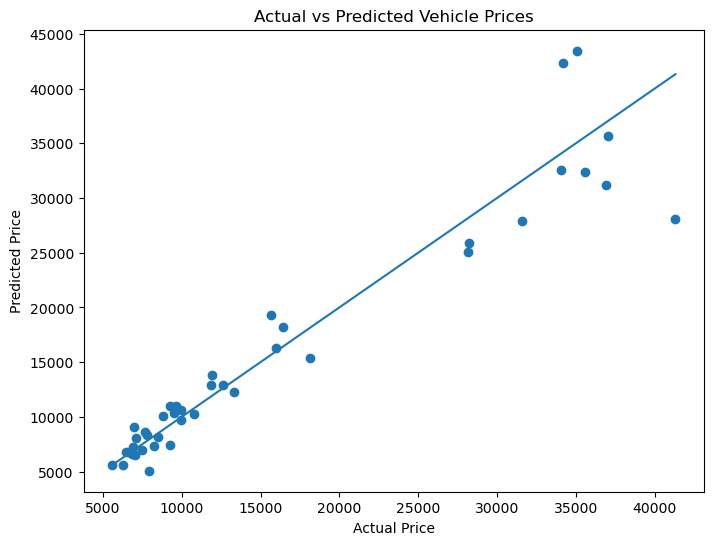

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_reg)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Vehicle Prices")

#reference line
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()])
plt.show()

## Result

The Linear Regression model was trained to predict vehicle price using the available automobile features. The intercept of the model was approximately 12573.68. The features with the largest coefficients included the number of cylinders, curb weight and compression ratio.

For example, curb weight had a positive coefficient of approximately 3287.37, which means that a higher value of this feature was associated with a higher predicted vehicle price. Some features such as the number of cylinders had negative coefficients because their effect is measured compared with reference category created during encoding.

The Actual vs Predicted Price graph shows that many predicted values are reasonably close to the actual values. some points are further from the reference line, especially for high priced vehicles showing larger prediction errors. Overall the relationships are reasonable because vehicle characteristics such as weight, enginerelated features and other specifications can influence automobile price.

# Question 3: Evaluating Linear Regression Performance

## Discussion

The performance of the Linear Regression model can be evaluated using different regression metrics. In this we will do Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE) and R Sqaure Score are used. These metrics help measure how close the predicted vehicle prices are to the actual prices.

In [10]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Regression evaluation metrics
mae =mean_absolute_error(y_test_reg, y_pred_reg)

mse =mean_squared_error(y_test_reg, y_pred_reg)

rmse =np.sqrt(mse)

r2 =r2_score(y_test_reg, y_pred_reg)

# Results
print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 2031.4906188046943
MSE: 10883796.738426425
RMSE: 3299.0599779977365
R² Score: 0.9110414074340111


## Result

The Linear Regression model achieved an MAE of 2031.49, means that the predicted vehicle prices were off by about 2031 on average. The MSE was 10883796.74 and the RMSE was 3299.06, showing that some larger prediction errors were present. The R² Score was 0.911, meaning that the model explained about 91.1% of the variation in vehicle prices.

The model shows reasonably good predictive performance because the R² score is high. The difference between the MAE and RMSE also shows that some larger errors affected the model. Based on the test results, the model appears to generalise reasonably well, although more information about training performance would be needed to clearly confirm overfitting or underfitting.

# Question 4: Logistic Regression – Luxury Car Classification

## Discussion

Logistic Regression is used when the target variable has categories or classes. In this task the model is used to predict whether a vehicle is a luxury car or not. The `LuxuryCar` variable has two classes where 1 represents a luxury car and 0 represents a non luxury car. The model will learn from the automobile features and predict the class of each vehicle.

In [11]:
from sklearn.linear_model import LogisticRegression

# Logistic Regression model
logistic_model =LogisticRegression(max_iter=10000)

# Training
logistic_model.fit(X_train_class_scaled, y_train_class)

# Prediction
y_pred_class =logistic_model.predict(X_test_class_scaled)

# Predict the probabilities
y_pred_probability =logistic_model.predict_proba(X_test_class_scaled)

print("First 10 predicted class labels:")
print(y_pred_class[:10])
print("\nFirst 10 predicted probabilities:")
print(y_pred_probability[:10])

First 10 predicted class labels:
[0 1 1 0 0 0 1 1 0 0]

First 10 predicted probabilities:
[[9.99016930e-01 9.83069950e-04]
 [2.13028820e-06 9.99997870e-01]
 [5.20116545e-07 9.99999480e-01]
 [9.64010640e-01 3.59893604e-02]
 [9.98389450e-01 1.61054963e-03]
 [9.99796337e-01 2.03663250e-04]
 [3.29883151e-04 9.99670117e-01]
 [5.40269013e-07 9.99999460e-01]
 [9.79997685e-01 2.00023148e-02]
 [5.86291016e-01 4.13708984e-01]]


In [12]:
# tTble of features and logistic regression coefficients
logistic_coefficients =pd.DataFrame({"Feature": X_encoded.columns,"Coefficient": logistic_model.coef_[0]})

# Sort by absolute coefficient value
logistic_coefficients["Absolute Coefficient"] = (logistic_coefficients["Coefficient"].abs())

logistic_coefficients =logistic_coefficients.sort_values(by="Absolute Coefficient",ascending=False)

print("Top 10 most influential features:")
print(logistic_coefficients.head(10))

Top 10 most influential features:
                 Feature  Coefficient  Absolute Coefficient
6            curb-weight     1.131109              1.131109
14           highway-mpg    -1.125349              1.125349
4                  width     0.868192              0.868192
13              city-mpg    -0.862524              0.862524
61      fuel-system_mpfi     0.810594              0.810594
11            horsepower     0.645072              0.645072
40  body-style_hatchback    -0.611827              0.611827
37      aspiration_turbo     0.552654              0.552654
18            make_dodge    -0.540116              0.540116
16              make_bmw     0.528000              0.528000


## Result

Logistic Regression was used to classify vehicles as luxury or nonluxury cars. This model is suitable because the `LuxuryCar` variable has two classes: 0 and 1. Unlike Linear Regression which predicts a continuous value such as vehicle price, Logistic Regression predicts the probability and class of a vehicle.

The most influential features included curb weight, highway miles per gallon, width, city miles per gallon, and horsepower. Curb weight had the largest positive coefficient of 1.131, while highway miles per gallon had a negative coefficient of -1.125. This means these features had strong influence on differntiating between luxury and nonluxury cars.

The results are reasonable because heavier, wider and more powerful vehicles may have a higher chance of being classified as luxury cars, while vehicles with higher fuel efficiency may be less likely to belong to the luxury category.

# Question 5: Evaluating Logistic Regression Performance

## Discussion

The Logistic Regression model can be evaluated using different classification metrics. In this task accuracy, precision, recall, F1-score, confusion matrix, ROC curve and AUC score are used. These measures help us understand how well the model can classify vehicles as luxury and nonluxury cars.

In [13]:
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

# Calculate classification metrics
accuracy =accuracy_score(y_test_class, y_pred_class)
precision =precision_score(y_test_class, y_pred_class)
recall =recall_score(y_test_class, y_pred_class)
f1 =f1_score(y_test_class, y_pred_class)

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1-score:",f1)

# Confusion Matrix
cm = confusion_matrix(y_test_class, y_pred_class)

print("\nConfusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_test_class, y_pred_class))

Accuracy: 0.9024390243902439
Precision: 0.8636363636363636
Recall: 0.95
F1-score: 0.9047619047619048

Confusion Matrix:
[[18  3]
 [ 1 19]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90        21
           1       0.86      0.95      0.90        20

    accuracy                           0.90        41
   macro avg       0.91      0.90      0.90        41
weighted avg       0.91      0.90      0.90        41



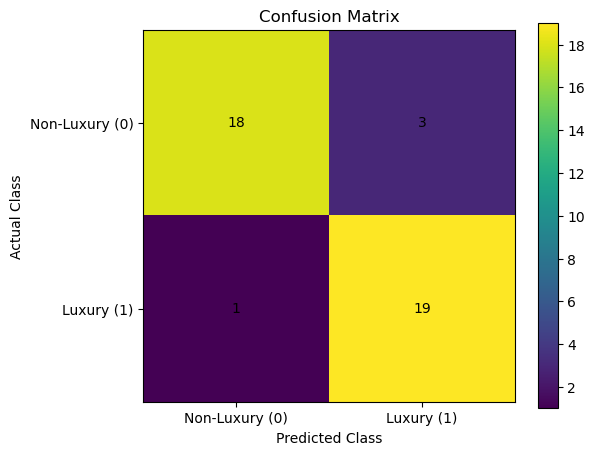

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.colorbar()
plt.xticks([0, 1], ["Non-Luxury (0)", "Luxury (1)"])
plt.yticks([0, 1], ["Non-Luxury (0)", "Luxury (1)"])
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()

AUC Score: 0.9928571428571429


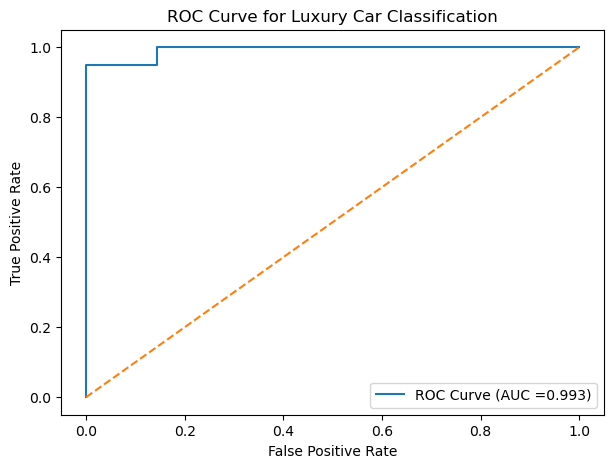

In [16]:
from sklearn.metrics import roc_curve, roc_auc_score

# probabilities for the LuxuryCar class (class 1)
y_pred_probability_class1 =y_pred_probability[:, 1]

# ROC values
fpr, tpr, thresholds =roc_curve(y_test_class,y_pred_probability_class1)

# AUC score
auc_score=roc_auc_score(y_test_class,y_pred_probability_class1)
print("AUC Score:",auc_score)

# Plot ROC Curve
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC ={auc_score:.3f})")
plt.plot([0, 1],[0, 1],linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Luxury Car Classification")
plt.legend()
plt.show()

## Result

The Logistic Regression model achieved an accuracy of 0.902 means that it correctly classified about 90.2% of the vehicles. The precision for the luxury car class was 0.864, the recall was 0.95. The F1-score was 0.905 showing good balance between precision and recall.

The confusion matrix showed that 18 nonluxury cars and 19 luxury cars were classified correctly. There were 3 nonluxury cars incorrectly predicted as luxury cars and 1 luxury car incorrectly predicted as a nonluxury car.

The model performed well for both classes. However, it was bit better at identifying luxury cars because the recall for class 1 was 0.95. The ROC curve also showed strong performance with an AUC score of approximately 0.993. This suggests that the model was very good at differntiating between luxury and nonluxury vehicles.